Importations et Configuration

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Ajout du chemin projet pour les imports
project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))

import config

# Configuration graphique
plt.style.use('ggplot')
%matplotlib inline

Device détecté: cpu


Chargement des métadonnées (Fichiers Bruts)

In [9]:
def get_pdf_stats():
    stats = []
    # On parcourt les fichiers dans data/raw
    for pdf_file in config.RAW_DATA_DIR.glob("*.pdf"):
        filename = pdf_file.name
        size_mb = pdf_file.stat().st_size / (1024 * 1024)
        
        # Logique de mapping des années
        if "2024" in filename:
            annee = "2024"
        elif "2025" in filename:
            annee = "2025"
        elif "SND30" in filename:
            annee = "2020"
        else:
            annee = "Inconnu"
            
        stats.append({
            "Fichier": filename,
            "Taille (MB)": round(size_mb, 2),
            "Année": annee
        })
        
    return pd.DataFrame(stats)

df_files = get_pdf_stats()
print("Aperçu des fichiers sources :")
display(df_files)

Aperçu des fichiers sources :


,Fichier,Taille (MB),Année
0,Loi_de_Finances_2024.pdf,19.56,2024
1,Loi_de_Finances_2025.pdf,14.63,2025
2,SND30_Document.pdf,1.35,2020


Chargement d'un échantillon du texte extrait :
On utilise ici les données après le premier passage de l'extracteur pour l'exploration.

In [4]:
import json

def load_sample_text(year):
    path = config.PROCESSED_DATA_DIR / f"processed_{year}.json"
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

data_24 = load_sample_text(2024)
data_25 = load_sample_text(2025)

print(f"Nombre d'articles extraits en 2024 : {len(data_24.get('articles', []))}")
print(f"Nombre d'articles extraits en 2025 : {len(data_25.get('articles', []))}")

Nombre d'articles extraits en 2024 : 57
Nombre d'articles extraits en 2025 : 51


Analyse de la longueur des articles

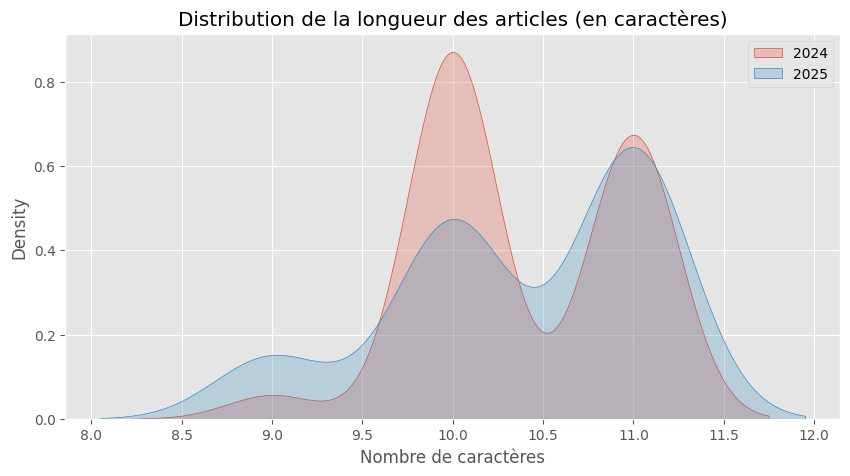

In [5]:
# Préparation des données pour la visualisation
len_24 = [len(str(art)) for art in data_24.get('articles', [])]
len_25 = [len(str(art)) for art in data_25.get('articles', [])]

plt.figure(figsize=(10, 5))
sns.kdeplot(len_24, label="2024", fill=True)
sns.kdeplot(len_25, label="2025", fill=True)
plt.title("Distribution de la longueur des articles (en caractères)")
plt.xlabel("Nombre de caractères")
plt.legend()
plt.show()

Visualisation par Nuage de Mots (WordCloud)

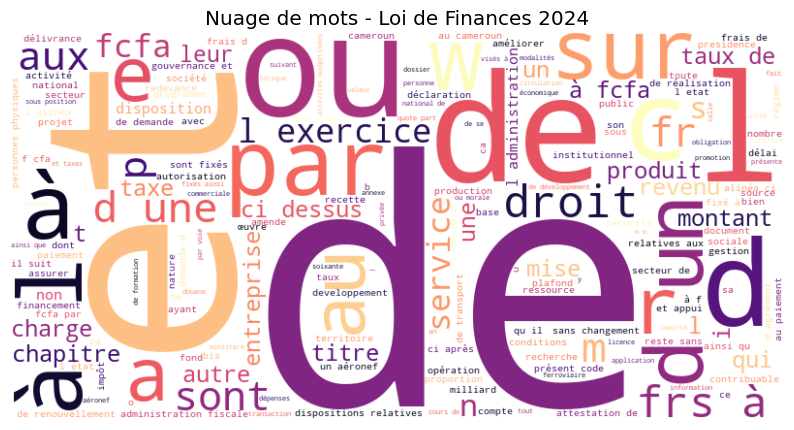

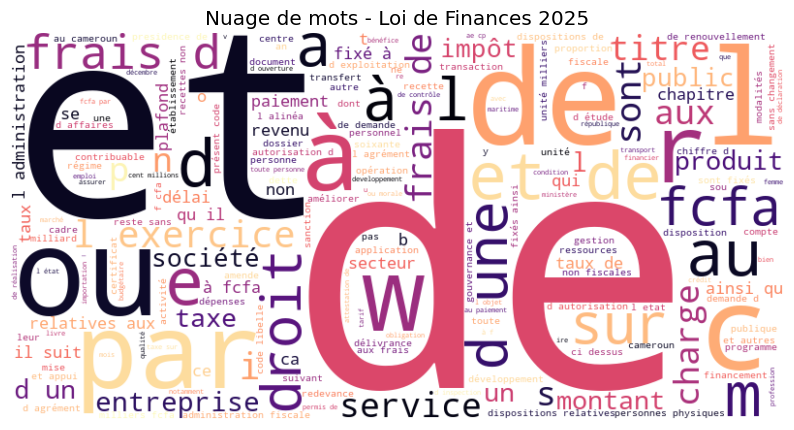

In [12]:
def generate_wc(data_dict, title):
    if not data_dict:
        print(f"⚠️ Dictionnaire vide pour {title}")
        return

    text_content = ""
    
    # 1. Extraction si 'sentences' existe
    if 'sentences' in data_dict and data_dict['sentences']:
        text_content = " ".join([str(s) for s in data_dict['sentences']])
    
    # 2. Extraction si 'articles' existe (Cas du dictionnaire de dictionnaires)
    elif 'articles' in data_dict and data_dict['articles']:
        articles_data = data_dict['articles']
        
        # Si c'est un dictionnaire (clés "0", "1", etc.)
        if isinstance(articles_data, dict):
            # On récupère les valeurs du dictionnaire
            values = articles_data.values()
            # On cherche le texte dans 'content', 'text' ou l'objet lui-même
            sample = list(values)[0]
            if isinstance(sample, dict):
                key = 'content' if 'content' in sample else 'text' if 'text' in sample else None
                if key:
                    text_content = " ".join([str(v.get(key, "")) for v in values])
                else:
                    text_content = " ".join([str(v) for v in values])
            else:
                text_content = " ".join([str(v) for v in values])
        
        # Si c'est une liste classique
        elif isinstance(articles_data, list):
            text_content = " ".join([str(a) for a in articles_data])

    # 3. Nettoyage final
    text_content = re.sub(r'\d+', '', text_content) # Enlever les nombres
    text_content = re.sub(r'[^\w\s]', ' ', text_content) # Enlever ponctuation

    if len(text_content.strip()) < 10:
        print(f"❌ Aucun mot trouvé. Structure détectée : {type(data_dict.get('articles'))}")
        return

    # 4. Affichage
    st_words = ["le", "la", "les", "des", "du", "en", "pour", "dans", "est", "article", "loi", "finances"]
    
    wc = WordCloud(width=800, height=400, background_color='white', 
                   stopwords=st_words, colormap='magma').generate(text_content)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Appel
generate_wc(data_24, "Nuage de mots - Loi de Finances 2024")
generate_wc(data_25, "Nuage de mots - Loi de Finances 2025")

Analyse des mots les plus fréquents (N-grams)

C:\Users\USER\AppData\Local\Temp\ipykernel_27760\547192242.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_24, x='Freq', y='Mot', ax=ax[0], palette='Blues_d').set(title='Top mots 2024')
C:\Users\USER\AppData\Local\Temp\ipykernel_27760\547192242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25, x='Freq', y='Mot', ax=ax[1], palette='Reds_d').set(title='Top mots 2025')


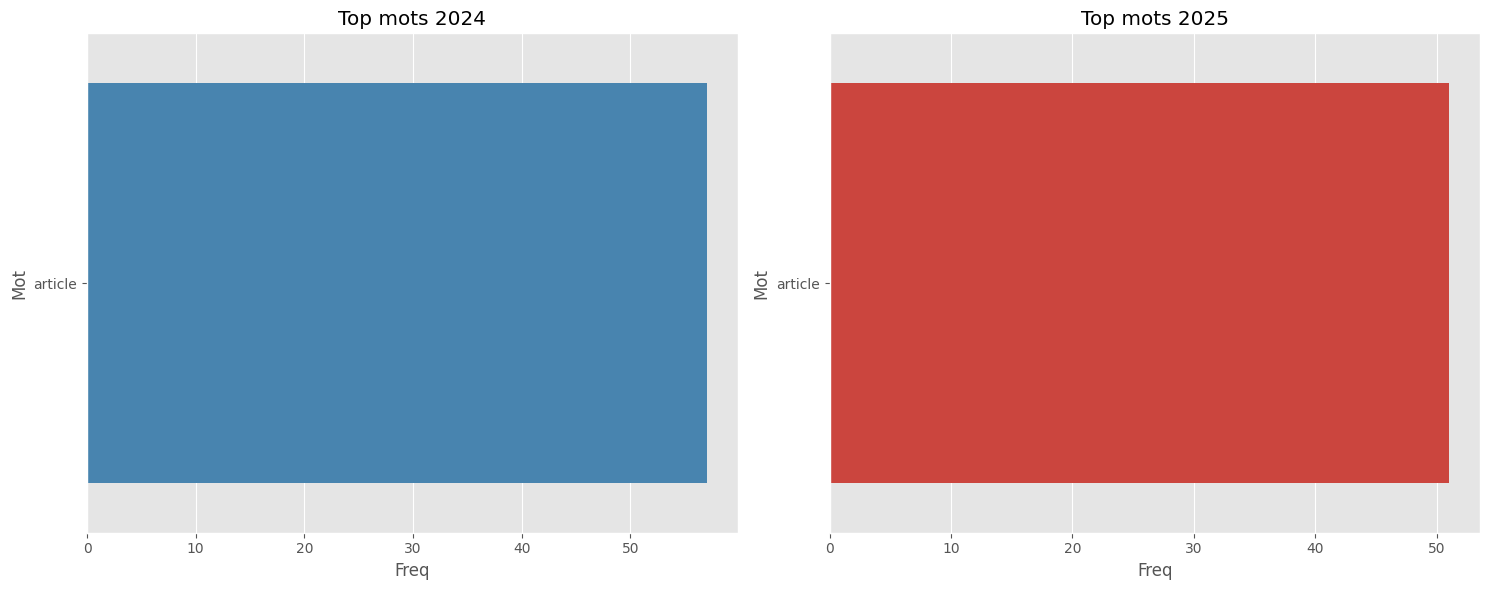

In [8]:
def get_top_words(text_list, n=15):
    full_text = " ".join([str(t).lower() for t in text_list])
    words = re.findall(r'\w{4,}', full_text) # Mots de plus de 4 lettres
    return Counter(words).most_common(n)

top_24 = pd.DataFrame(get_top_words(data_24.get('articles', [])), columns=['Mot', 'Freq'])
top_25 = pd.DataFrame(get_top_words(data_25.get('articles', [])), columns=['Mot', 'Freq'])

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=top_24, x='Freq', y='Mot', ax=ax[0], palette='Blues_d').set(title='Top mots 2024')
sns.barplot(data=top_25, x='Freq', y='Mot', ax=ax[1], palette='Reds_d').set(title='Top mots 2025')
plt.tight_layout()
plt.show()

Conclusion de l'exploration

**Observations :**
1. Les documents sont structurellement similaires (longueur d'articles comparable).
2. Le vocabulaire est très technique et répétitif (mots clés : budget, dépenses, État, recettes).
3. La nécessité d'utiliser des **Embeddings sémantiques** (BERT) est confirmée car les simples fréquences de mots ne permettent pas de distinguer les nuances budgétaires stratégiques.